# 06 - Temporal Feature Screening and Final Model Decision

## Purpose

Notebook 05 showed that the remaining missed failures were **not mainly a threshold-tuning problem**. Many missed failed drives had weak, sparse, or intermittent SMART signals, while many false-positive healthy drives showed persistent abnormal behavior.

This final technical notebook therefore tests one narrow hypothesis:

> **Can a small set of targeted temporal SMART features improve the selected Logistic Regression-style baseline enough to justify the added complexity?**

This notebook is a cleaned reproduction of the completed Notebook 06 experiment history. It intentionally preserves the final corrected evaluation rather than every abandoned intermediate attempt.

### Experiment flow

1. Reproduce the reduced 10% / 3-fold temporal screening experiment.
2. Compare Baseline v1 and Temporal v2a under identical grouped folds and the same SGD logistic estimator.
3. Save both `y_prob` and the unsquashed `decision_score` for every validation row.
4. Treat the original fixed `0.70` probability comparison as a **diagnostic only**, not as the final operating comparison.
5. Rank drives within each fold using raw `decision_function` scores.
6. Compare the two models at identical alert budgets: 0.5%, 1%, 2%, and 5% of drives per fold.
7. Inspect score saturation and boundary ties.
8. Make the final model decision.

The authoritative historical result is **`RETAIN_BASELINE_V1`** unless a full reproduction run materially contradicts the saved reference outputs.


## Why the evaluation method changed

The first matched-workload attempt (historical Notebook 06b) pooled SGD probabilities. That approach was rejected because many probabilities saturated at exactly `0` or `1`, destroying useful ordering information and creating large ties.

The corrected approach uses:

```python
model.decision_function(X_valid)
```

for ranking. Probabilities are still retained for conventional PR-AUC / ROC-AUC diagnostics, but the final operational comparison is based on **raw decision scores and equal alert budgets inside each fold**.

This distinction matters because the screening estimator is intentionally a fast SGD-based logistic classifier. Its probabilities are not assumed to share the calibration of the original full Logistic Regression baseline.


In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from pathlib import Path
from time import perf_counter
import gc
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

DATA_FILENAME = "df_cleaned.parquet"
SERIAL_COLUMN = "serial_number"
DATE_COLUMN = "date"
TARGET_COLUMN = "failure"

BASE_FEATURES = [
    "smart_5_raw",
    "smart_197_raw",
    "smart_198_raw",
]

# Reduced screening configuration from the authoritative experiment.
SAMPLE_FRACTION = 0.10
N_SPLITS = 3
RANDOM_STATE = 42

SGD_PARAMS = {
    "loss": "log_loss",
    "penalty": "l2",
    "alpha": 0.0001,
    "class_weight": "balanced",
    "max_iter": 100,
    "tol": 1e-3,
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 5,
    "average": True,
    "random_state": RANDOM_STATE,
}

ALERT_BUDGETS = [0.005, 0.01, 0.02, 0.05]
EARLY_WARNING_DAYS = 7

# Reliability diagnostics used by the corrected evaluation.
MAX_ACCEPTABLE_TOP_SCORE_SHARE = 0.01
MAX_ACCEPTABLE_BOUNDARY_TIE_SHARE = 0.10

SEARCH_ROOTS = [
    Path("/kaggle/working"),
    Path("/kaggle/input"),
    Path("."),
]

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Sample fraction: {SAMPLE_FRACTION:.0%}")
print(f"Grouped folds: {N_SPLITS}")
print("Estimator: SGDClassifier(loss='log_loss')")
print("Alert budgets:", [f"{x:.1%}" for x in ALERT_BUDGETS])


Sample fraction: 10%
Grouped folds: 3
Estimator: SGDClassifier(loss='log_loss')
Alert budgets: ['0.5%', '1.0%', '2.0%', '5.0%']


In [2]:
# ============================================================
# 2. Locate the cleaned dataset
# ============================================================

def find_file(filename: str) -> Path:
    for root in SEARCH_ROOTS:
        direct = root / filename
        if direct.exists():
            return direct

        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]

    raise FileNotFoundError(
        f"Could not find {filename}. Attach the Kaggle dataset that contains "
        f"{filename} before running this notebook."
    )


DATA_PATH = find_file(DATA_FILENAME)
print("Using:", DATA_PATH)


Using: /kaggle/input/datasets/emilywanglovescats/blackblaze-data-2023-cleaned/df_cleaned.parquet


## Targeted temporal feature set

The temporal branch is deliberately small and directly tied to the Notebook 05 error analysis. For each of the three baseline SMART attributes, it adds:

- a **non-zero indicator** — whether the signal is currently abnormal;
- **change from the previous available observation** — sudden deterioration;
- **maximum over the current and previous six observations** — recent peaks;
- **non-zero count over the current seven observations** — persistence.

One combined feature counts how many of the three SMART attributes are currently non-zero.

This produces **13 engineered features**, or **16 total features** including the three baseline SMART attributes. Rolling windows are observation-based, not guaranteed calendar-day windows.

Features are created from each drive's chronological history **before row sampling**. Every engineered feature uses only the current or earlier observations; no future observations are used.


In [3]:
# ============================================================
# 3. Load only the columns required by this experiment
# ============================================================

required_columns = [
    SERIAL_COLUMN,
    DATE_COLUMN,
    TARGET_COLUMN,
    *BASE_FEATURES,
]

try:
    df = pd.read_parquet(DATA_PATH, columns=required_columns)
except Exception as exc:
    raise RuntimeError(
        "Could not load the required columns from df_cleaned.parquet. "
        f"Required columns: {required_columns}"
    ) from exc

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")
df[TARGET_COLUMN] = (
    pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
    .fillna(0)
    .astype("int8")
)

for feature in BASE_FEATURES:
    df[feature] = pd.to_numeric(df[feature], errors="coerce")

df = (
    df.dropna(subset=[SERIAL_COLUMN, DATE_COLUMN])
    .sort_values([SERIAL_COLUMN, DATE_COLUMN])
    .reset_index(drop=True)
)

print(f"Rows loaded: {len(df):,}")
print(f"Unique drives: {df[SERIAL_COLUMN].nunique():,}")
print(f"Failure rows: {df[TARGET_COLUMN].sum():,}")
print(f"Positive rate: {df[TARGET_COLUMN].mean():.6%}")


Rows loaded: 24,790,999
Unique drives: 281,346
Failure rows: 1,057
Positive rate: 0.004264%


In [4]:
# ============================================================
# 4. Create the reduced temporal feature set
# ============================================================

def add_reduced_temporal_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    nonzero_columns = []

    for feature in BASE_FEATURES:
        nonzero_column = f"{feature}_nonzero"
        delta_column = f"{feature}_delta_1obs"
        rolling_max_column = f"{feature}_rolling_max_7obs"
        nonzero_count_column = f"{feature}_nonzero_count_7obs"

        result[nonzero_column] = (
            result[feature].fillna(0).gt(0).astype("int8")
        )
        nonzero_columns.append(nonzero_column)

        result[delta_column] = (
            result.groupby(
                SERIAL_COLUMN,
                observed=True,
                sort=False,
            )[feature]
            .diff()
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

        result[rolling_max_column] = (
            result.groupby(
                SERIAL_COLUMN,
                observed=True,
                sort=False,
            )[feature]
            .rolling(window=7, min_periods=1)
            .max()
            .reset_index(level=0, drop=True)
        )

        result[nonzero_count_column] = (
            result.groupby(
                SERIAL_COLUMN,
                observed=True,
                sort=False,
            )[nonzero_column]
            .rolling(window=7, min_periods=1)
            .sum()
            .reset_index(level=0, drop=True)
        )

    result["abnormal_smart_count"] = (
        result[nonzero_columns].sum(axis=1).astype("int8")
    )
    return result


feature_start = perf_counter()
df = add_reduced_temporal_features(df)
feature_seconds = perf_counter() - feature_start

ENGINEERED_FEATURES = [
    "smart_5_raw_nonzero",
    "smart_197_raw_nonzero",
    "smart_198_raw_nonzero",
    "abnormal_smart_count",
    "smart_5_raw_delta_1obs",
    "smart_197_raw_delta_1obs",
    "smart_198_raw_delta_1obs",
    "smart_5_raw_rolling_max_7obs",
    "smart_197_raw_rolling_max_7obs",
    "smart_198_raw_rolling_max_7obs",
    "smart_5_raw_nonzero_count_7obs",
    "smart_197_raw_nonzero_count_7obs",
    "smart_198_raw_nonzero_count_7obs",
]

V2_FEATURES = BASE_FEATURES + ENGINEERED_FEATURES

assert len(BASE_FEATURES) == 3
assert len(ENGINEERED_FEATURES) == 13
assert len(V2_FEATURES) == 16

print(f"Feature generation time: {feature_seconds:,.1f} seconds")
print(f"Baseline feature count: {len(BASE_FEATURES)}")
print(f"Temporal v2a feature count: {len(V2_FEATURES)}")


Feature generation time: 122.6 seconds
Baseline feature count: 3
Temporal v2a feature count: 16


In [5]:
# ============================================================
# 5. Create the fixed 10% screening sample
# ============================================================

sampled_df = (
    df.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_STATE)
    .sort_values([SERIAL_COLUMN, DATE_COLUMN])
    .reset_index(drop=True)
)

print(f"Sampled rows: {len(sampled_df):,}")
print(f"Sampled unique drives: {sampled_df[SERIAL_COLUMN].nunique():,}")
print(f"Sampled failure rows: {sampled_df[TARGET_COLUMN].sum():,}")
print(f"Sampled positive rate: {sampled_df[TARGET_COLUMN].mean():.6%}")

if sampled_df[TARGET_COLUMN].sum() < N_SPLITS:
    raise ValueError("Too few failure rows for the requested grouped folds.")

# Full-history feature construction is complete; release the full table.
del df
gc.collect()


Sampled rows: 2,479,100
Sampled unique drives: 279,495
Sampled failure rows: 102
Sampled positive rate: 0.004114%


0

In [6]:
# ============================================================
# 6. Freeze leakage-safe StratifiedGroupKFold assignments
# ============================================================

y = sampled_df[TARGET_COLUMN]
groups = sampled_df[SERIAL_COLUMN]

splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_indices = []
fold_assignments = np.full(len(sampled_df), -1, dtype="int8")

for fold_number, (train_idx, val_idx) in enumerate(
    splitter.split(sampled_df[BASE_FEATURES], y, groups)
):
    fold_indices.append((train_idx, val_idx))
    fold_assignments[val_idx] = fold_number

assert (fold_assignments >= 0).all()
sampled_df["fold"] = fold_assignments

fold_check = (
    sampled_df.groupby("fold", observed=True)
    .agg(
        rows=(TARGET_COLUMN, "size"),
        failure_rows=(TARGET_COLUMN, "sum"),
        drives=(SERIAL_COLUMN, "nunique"),
    )
    .reset_index()
)
fold_check["positive_rate"] = fold_check["failure_rows"] / fold_check["rows"]
display(fold_check)

drive_fold_counts = sampled_df.groupby(SERIAL_COLUMN, observed=True)["fold"].nunique()
assert drive_fold_counts.max() == 1

print("Grouped-fold leakage check passed: every drive belongs to exactly one fold.")


,fold,rows,failure_rows,drives,positive_rate
0,0,824776,31,93171,0.000038
1,1,827086,37,93162,0.000045
2,2,827238,34,93162,0.000041


Grouped-fold leakage check passed: every drive belongs to exactly one fold.


In [7]:
# ============================================================
# 7. Build identical SGD logistic pipelines
# ============================================================

def make_pipeline(feature_columns):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                feature_columns,
            ),
        ],
        remainder="drop",
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", SGDClassifier(**SGD_PARAMS)),
        ]
    )


print("Baseline v1 and Temporal v2a use identical preprocessing and estimator settings.")


Baseline v1 and Temporal v2a use identical preprocessing and estimator settings.


## Controlled screening run

The only experimental difference below is the feature set:

- **Baseline v1 screen:** 3 raw SMART attributes.
- **Temporal v2a screen:** the same 3 raw attributes + 13 targeted temporal features.

Both models use the same sampled rows, the same frozen validation indices, the same preprocessing, and the same estimator settings.

Crucially, the notebook saves **both**:

- `y_prob` for standard ranking metrics;
- `decision_score` for the corrected operational comparison.


In [8]:
# ============================================================
# 8. Train both versions on identical folds
# ============================================================

model_specs = {
    "baseline_v1_screen": BASE_FEATURES,
    "temporal_v2a_screen": V2_FEATURES,
}

oof_predictions = {
    model_name: np.full(len(sampled_df), np.nan)
    for model_name in model_specs
}

oof_decision_scores = {
    model_name: np.full(len(sampled_df), np.nan)
    for model_name in model_specs
}

metric_records = []

for fold_number, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"\n{'=' * 64}")
    print(f"FOLD {fold_number}")
    print(f"{'=' * 64}")

    train_frame = sampled_df.iloc[train_idx]
    val_frame = sampled_df.iloc[val_idx]
    y_train = train_frame[TARGET_COLUMN]
    y_val = val_frame[TARGET_COLUMN]

    for model_name, feature_columns in model_specs.items():
        print(f"\nStarting {model_name}")
        print(f"Training rows: {len(train_frame):,}")
        print(f"Validation rows: {len(val_frame):,}")
        print(f"Input feature count: {len(feature_columns)}")

        pipeline = make_pipeline(feature_columns)

        fit_start = perf_counter()
        pipeline.fit(train_frame[feature_columns], y_train)
        fit_seconds = perf_counter() - fit_start

        prediction_start = perf_counter()
        probabilities = pipeline.predict_proba(val_frame[feature_columns])[:, 1]
        decision_scores = pipeline.decision_function(val_frame[feature_columns])
        prediction_seconds = perf_counter() - prediction_start

        pr_auc = average_precision_score(y_val, probabilities)
        roc_auc = roc_auc_score(y_val, probabilities)

        oof_predictions[model_name][val_idx] = probabilities
        oof_decision_scores[model_name][val_idx] = decision_scores

        metric_records.append(
            {
                "model": model_name,
                "fold": fold_number,
                "training_rows": len(train_frame),
                "validation_rows": len(val_frame),
                "validation_failure_rows": int(y_val.sum()),
                "feature_count": len(feature_columns),
                "fit_seconds": fit_seconds,
                "prediction_seconds": prediction_seconds,
                "pr_auc": pr_auc,
                "roc_auc": roc_auc,
            }
        )

        print(f"Fit complete in {fit_seconds:,.1f} seconds")
        print(f"PR-AUC={pr_auc:.6f}, ROC-AUC={roc_auc:.6f}")

        del pipeline, probabilities, decision_scores
        gc.collect()

for model_name in model_specs:
    assert not np.isnan(oof_predictions[model_name]).any()
    assert not np.isnan(oof_decision_scores[model_name]).any()

fold_metrics = pd.DataFrame(metric_records)
display(fold_metrics)



FOLD 0

Starting baseline_v1_screen
Training rows: 1,654,324
Validation rows: 824,776
Input feature count: 3
Fit complete in 3.9 seconds
PR-AUC=0.000038, ROC-AUC=0.500000

Starting temporal_v2a_screen
Training rows: 1,654,324
Validation rows: 824,776
Input feature count: 16
Fit complete in 8.8 seconds
PR-AUC=0.000036, ROC-AUC=0.483873

FOLD 1

Starting baseline_v1_screen
Training rows: 1,652,014
Validation rows: 827,086
Input feature count: 3
Fit complete in 3.9 seconds
PR-AUC=0.000045, ROC-AUC=0.500000

Starting temporal_v2a_screen
Training rows: 1,652,014
Validation rows: 827,086
Input feature count: 16
Fit complete in 8.7 seconds
PR-AUC=0.000628, ROC-AUC=0.857629

FOLD 2

Starting baseline_v1_screen
Training rows: 1,651,862
Validation rows: 827,238
Input feature count: 3
Fit complete in 3.9 seconds
PR-AUC=0.000851, ROC-AUC=0.894100

Starting temporal_v2a_screen
Training rows: 1,651,862
Validation rows: 827,238
Input feature count: 16
Fit complete in 8.8 seconds
PR-AUC=0.000680, ROC

,model,fold,training_rows,validation_rows,validation_failure_rows,feature_count,fit_seconds,prediction_seconds,pr_auc,roc_auc
0,baseline_v1_screen,0,1654324,824776,31,3,3.862812,0.138031,0.000038,0.500000
1,temporal_v2a_screen,0,1654324,824776,31,16,8.812601,0.607820,0.000036,0.483873
2,baseline_v1_screen,1,1652014,827086,37,3,3.854577,0.136748,0.000045,0.500000
3,temporal_v2a_screen,1,1652014,827086,37,16,8.710794,0.644073,0.000628,0.857629
4,baseline_v1_screen,2,1651862,827238,34,3,3.913647,0.138296,0.000851,0.894100
5,temporal_v2a_screen,2,1651862,827238,34,16,8.806817,0.651471,0.000680,0.891069


,model,mean_pr_auc,std_pr_auc,min_pr_auc,max_pr_auc,mean_roc_auc,std_roc_auc,total_fit_seconds,mean_fit_seconds
0,baseline_v1_screen,0.000311,0.000467,0.000038,0.000851,0.631367,0.227534,11.631036,3.877012
1,temporal_v2a_screen,0.000448,0.000358,0.000036,0.000680,0.744190,0.226061,26.330213,8.776738


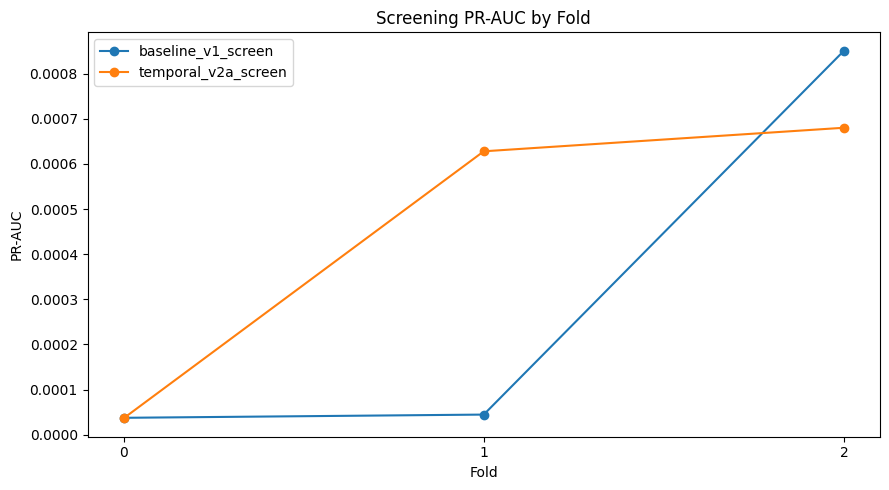

In [9]:
# ============================================================
# 9. Fold-level screening summary
# ============================================================

fold_summary = (
    fold_metrics.groupby("model", observed=True)
    .agg(
        mean_pr_auc=("pr_auc", "mean"),
        std_pr_auc=("pr_auc", "std"),
        min_pr_auc=("pr_auc", "min"),
        max_pr_auc=("pr_auc", "max"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        total_fit_seconds=("fit_seconds", "sum"),
        mean_fit_seconds=("fit_seconds", "mean"),
    )
    .reset_index()
)

display(fold_summary)

plt.figure(figsize=(9, 5))
for model_name, group in fold_metrics.groupby("model", observed=True):
    plt.plot(group["fold"], group["pr_auc"], marker="o", label=model_name)

plt.title("Screening PR-AUC by Fold")
plt.xlabel("Fold")
plt.ylabel("PR-AUC")
plt.xticks(range(N_SPLITS))
plt.legend()
plt.tight_layout()
plt.show()


### Screening interpretation

In the authoritative run, Temporal v2a improved the **mean row-level ranking metrics** within this controlled screen:

- mean PR-AUC: approximately **0.000311 → 0.000448**;
- mean ROC-AUC: approximately **0.631 → 0.744**.

That was enough to justify a closer operational comparison, but **not** enough to promote the temporal model. The fixed `0.70` threshold from the original Logistic Regression baseline cannot be transferred directly to these SGD screening probabilities.

The next cells therefore ignore that threshold as a final decision rule and evaluate the models at **matched alert workloads**.


In [10]:
# ============================================================
# 10. Build OOF tables with both probability and decision score
# ============================================================

common_columns = sampled_df[
    ["fold", SERIAL_COLUMN, DATE_COLUMN, TARGET_COLUMN]
].copy()

oof_tables = {}

for model_name, probabilities in oof_predictions.items():
    table = common_columns.rename(columns={TARGET_COLUMN: "y_true"}).copy()
    table["y_prob"] = probabilities
    table["decision_score"] = oof_decision_scores[model_name]
    table["model_version"] = model_name
    oof_tables[model_name] = table

required_oof_columns = {
    "fold",
    "serial_number",
    "date",
    "y_true",
    "y_prob",
    "decision_score",
    "model_version",
}

for model_name, table in oof_tables.items():
    assert required_oof_columns.issubset(table.columns)
    assert table["decision_score"].notna().all()

print("Corrected OOF schema verified for both models.")
display(oof_tables["baseline_v1_screen"].head())


Corrected OOF schema verified for both models.


,fold,serial_number,date,y_true,y_prob,decision_score,model_version
0,1,000a43e7dee60010,2023-10-13,0,1.000000,17.957598,baseline_v1_screen
1,1,000a43e7dee60010,2023-10-30,0,1.000000,17.957598,baseline_v1_screen
2,1,000a43e7dee60010,2023-11-10,0,1.000000,17.957598,baseline_v1_screen
3,1,000a43e7dee60010,2023-11-23,0,1.000000,17.957598,baseline_v1_screen
4,1,000a43e7dee60010,2023-12-15,0,1.000000,17.957598,baseline_v1_screen


In [11]:
# ============================================================
# 11. Probability saturation diagnostic
# ============================================================

# This cell documents why probability-only matched-workload ranking was rejected.
def probability_saturation_summary(oof_frame, model_name):
    frame = oof_frame.copy()
    frame[DATE_COLUMN] = pd.to_datetime(frame[DATE_COLUMN])

    failure_dates = (
        frame.loc[frame["y_true"] == 1]
        .groupby(SERIAL_COLUMN, observed=True)[DATE_COLUMN]
        .min()
        .rename("failure_date")
    )
    frame = frame.merge(failure_dates, on=SERIAL_COLUMN, how="left")
    frame = frame[
        frame["failure_date"].isna()
        | (frame[DATE_COLUMN] <= frame["failure_date"])
    ].copy()

    drive_prob = (
        frame.groupby(["fold", SERIAL_COLUMN], observed=True)["y_prob"]
        .max()
        .rename("drive_max_probability")
        .reset_index()
    )

    rows = []
    for fold, fold_df in drive_prob.groupby("fold"):
        rows.append(
            {
                "model": model_name,
                "fold": int(fold),
                "drives": len(fold_df),
                "unique_probabilities": fold_df["drive_max_probability"].nunique(),
                "share_exactly_1": (fold_df["drive_max_probability"] == 1.0).mean(),
                "share_exactly_0": (fold_df["drive_max_probability"] == 0.0).mean(),
            }
        )
    return rows


probability_diagnostics = pd.DataFrame(
    probability_saturation_summary(
        oof_tables["baseline_v1_screen"], "baseline_v1"
    )
    + probability_saturation_summary(
        oof_tables["temporal_v2a_screen"], "temporal_v2a"
    )
)

display(probability_diagnostics)
print(
    "Operational ranking below uses decision_score, not y_prob. "
    "This preserves ordering that can be lost after the logistic transform."
)


,model,fold,drives,unique_probabilities,share_exactly_1,share_exactly_0
0,baseline_v1,0,93171,1,1.000000,0.000000
1,baseline_v1,1,93162,1,1.000000,0.000000
2,baseline_v1,2,93162,18,0.031579,0.000000
3,temporal_v2a,0,93171,1,1.000000,0.000000
4,temporal_v2a,1,93162,4,0.045373,0.000000
5,temporal_v2a,2,93162,3,0.045501,0.000000


Operational ranking below uses decision_score, not y_prob. This preserves ordering that can be lost after the logistic transform.


## Corrected fold-normalized matched-workload evaluation

The final comparison works at the **physical-drive level**.

For failed drives, only observations on or before the failure date are eligible. Each drive receives its maximum eligible raw decision score. Drives are then ranked **inside their assigned fold**, and the same percentage of drives is alerted in each fold for both models.

This gives a fairer operational question:

> At the same alert workload, which model finds more failed drives, and with what warning lead time?

Alert budgets are 0.5%, 1%, 2%, and 5% of drives per fold.


In [12]:
# ============================================================
# 12. Standardize OOF tables and build eligible drive-level data
# ============================================================

def standardize_oof(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    required = [
        "serial_number", "date", "y_true", "fold", "decision_score"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"{model_name}: missing required OOF columns: {missing}")

    out = pd.DataFrame(
        {
            "serial_number": df["serial_number"].astype(str),
            "date": pd.to_datetime(df["date"], errors="coerce"),
            "y_true": pd.to_numeric(df["y_true"], errors="coerce"),
            "fold": pd.to_numeric(df["fold"], errors="coerce"),
            "y_score": pd.to_numeric(df["decision_score"], errors="coerce"),
        }
    ).dropna()

    out["y_true"] = out["y_true"].astype(int)
    out["fold"] = out["fold"].astype(int)
    out["model"] = model_name
    out["score_type"] = "decision_function"

    if not out["y_true"].isin([0, 1]).all():
        raise ValueError(f"{model_name}: target contains values other than 0 and 1.")

    return out.sort_values(["fold", "serial_number", "date"]).reset_index(drop=True)


def drive_labels(frame):
    return frame.groupby("serial_number", observed=True)["y_true"].max().sort_index()


baseline_oof = standardize_oof(oof_tables["baseline_v1_screen"], "baseline_v1")
temporal_oof = standardize_oof(oof_tables["temporal_v2a_screen"], "temporal_v2a")

baseline_labels = drive_labels(baseline_oof)
temporal_labels = drive_labels(temporal_oof)
common_drives = baseline_labels.index.intersection(temporal_labels.index)

baseline_oof = baseline_oof[baseline_oof["serial_number"].isin(common_drives)].copy()
temporal_oof = temporal_oof[temporal_oof["serial_number"].isin(common_drives)].copy()

baseline_labels = drive_labels(baseline_oof)
temporal_labels = drive_labels(temporal_oof)

label_mismatches = int((baseline_labels != temporal_labels).sum())
if label_mismatches:
    raise ValueError(
        f"Drive-level labels disagree for {label_mismatches} common drives."
    )

for model_name, frame in [("baseline_v1", baseline_oof), ("temporal_v2a", temporal_oof)]:
    leaking_drives = int(
        (frame.groupby("serial_number")["fold"].nunique() > 1).sum()
    )
    if leaking_drives:
        raise ValueError(f"{model_name}: {leaking_drives} drives appear in multiple folds.")

print(f"Common drives: {len(common_drives):,}")
print(f"Failed drives: {int(baseline_labels.sum()):,}")
print("Folds:", sorted(baseline_oof["fold"].unique().tolist()))


Common drives: 279,495
Failed drives: 102
Folds: [0, 1, 2]


In [13]:
# ============================================================
# 13. Build eligible row-level and drive-level data
# ============================================================

def build_drive_data(frame: pd.DataFrame):
    frame = frame.sort_values(["serial_number", "date"]).copy()

    failure_dates = (
        frame.loc[frame["y_true"] == 1]
        .groupby("serial_number", observed=True)["date"]
        .min()
        .rename("failure_date")
    )

    frame = frame.merge(failure_dates, on="serial_number", how="left")
    frame["drive_failed"] = frame["failure_date"].notna().astype(int)

    eligible = frame[
        (frame["drive_failed"] == 0)
        | (frame["date"] <= frame["failure_date"])
    ].copy()

    drive_df = (
        eligible.groupby("serial_number", observed=True)
        .agg(
            fold=("fold", "first"),
            drive_failed=("drive_failed", "max"),
            failure_date=("failure_date", "first"),
            drive_score=("y_score", "max"),
            first_observation=("date", "min"),
            last_eligible_observation=("date", "max"),
            eligible_rows=("date", "size"),
            score_type=("score_type", "first"),
        )
        .reset_index()
    )

    drive_df["within_fold_percentile"] = (
        drive_df.groupby("fold")["drive_score"]
        .rank(method="average", pct=True)
    )

    return eligible, drive_df


baseline_rows, baseline_drives = build_drive_data(baseline_oof)
temporal_rows, temporal_drives = build_drive_data(temporal_oof)

print("Drive-level shapes:")
print("  baseline_v1:", baseline_drives.shape)
print("  temporal_v2a:", temporal_drives.shape)


Drive-level shapes:
  baseline_v1: (279495, 10)
  temporal_v2a: (279495, 10)


In [14]:
# ============================================================
# 14. Decision-score saturation and tie diagnostics
# ============================================================

def score_diagnostics(drive_df: pd.DataFrame, model_name: str):
    rows = []

    for fold, fold_df in drive_df.groupby("fold"):
        max_score = fold_df["drive_score"].max()
        min_score = fold_df["drive_score"].min()

        top_ties = int((fold_df["drive_score"] == max_score).sum())
        bottom_ties = int((fold_df["drive_score"] == min_score).sum())

        rows.append(
            {
                "model": model_name,
                "fold": int(fold),
                "score_type": fold_df["score_type"].iloc[0],
                "drives": len(fold_df),
                "unique_scores": fold_df["drive_score"].nunique(),
                "unique_score_share": fold_df["drive_score"].nunique() / len(fold_df),
                "min_score": min_score,
                "median_score": fold_df["drive_score"].median(),
                "max_score": max_score,
                "drives_at_max_score": top_ties,
                "share_at_max_score": top_ties / len(fold_df),
                "drives_at_min_score": bottom_ties,
                "share_at_min_score": bottom_ties / len(fold_df),
            }
        )

    return rows


diagnostics = pd.DataFrame(
    score_diagnostics(baseline_drives, "baseline_v1")
    + score_diagnostics(temporal_drives, "temporal_v2a")
)

display(diagnostics)


,model,fold,score_type,drives,unique_scores,unique_score_share,min_score,median_score,max_score,drives_at_max_score,share_at_max_score,drives_at_min_score,share_at_min_score
0,baseline_v1,0,decision_function,93171,996,0.010690,21.386780,21.386780,"842,203.562500",1,0.000011,89057,0.955845
1,baseline_v1,1,decision_function,93162,981,0.010530,17.957598,17.957598,"35,905.949219",1,0.000011,88971,0.955014
2,baseline_v1,2,decision_function,93162,1025,0.011002,7.295448,7.295448,"1,109,078.500000",1,0.000011,88962,0.954917
3,temporal_v2a,0,decision_function,93171,1156,0.012407,265.717745,265.717745,"1,872,617.758708",1,0.000011,89022,0.955469
4,temporal_v2a,1,decision_function,93162,1196,0.012838,-16.675115,-16.675115,"880,614.042085",1,0.000011,88917,0.954434
5,temporal_v2a,2,decision_function,93162,1233,0.013235,-132.929579,-132.929579,"16,324,869.206258",1,0.000011,88919,0.954456


In [15]:
# ============================================================
# 15. Fold-normalized exact-budget evaluator
# ============================================================

def evaluate_model_at_budget(
    drive_df: pd.DataFrame,
    eligible_rows: pd.DataFrame,
    model_name: str,
    budget_fraction: float,
):
    selected_parts = []
    fold_detail_rows = []
    boundary_detail_rows = []

    for fold, fold_df in drive_df.groupby("fold", sort=True):
        ranked = fold_df.sort_values(
            ["drive_score", "serial_number"],
            ascending=[False, True],
            kind="mergesort",
        ).reset_index(drop=True)

        n_fold = len(ranked)
        n_alert = max(1, math.ceil(n_fold * budget_fraction))

        selected = ranked.iloc[:n_alert].copy()
        selected["alerted"] = True
        selected["budget_fraction"] = budget_fraction
        selected_parts.append(selected)

        cutoff_score = selected["drive_score"].min()
        cutoff_percentile = selected["within_fold_percentile"].min()

        tied_at_cutoff = int((ranked["drive_score"] == cutoff_score).sum())
        selected_from_cutoff_tie = int(
            (selected["drive_score"] == cutoff_score).sum()
        )
        boundary_tie_share = tied_at_cutoff / n_fold

        failed_total = int(ranked["drive_failed"].sum())
        failed_detected = int(selected["drive_failed"].sum())

        fold_detail_rows.append(
            {
                "model": model_name,
                "fold": int(fold),
                "alert_budget_fraction": budget_fraction,
                "alert_budget_percent": budget_fraction * 100,
                "fold_drives": n_fold,
                "fold_drives_alerted": n_alert,
                "score_cutoff": cutoff_score,
                "percentile_cutoff": cutoff_percentile,
                "failed_drives_total": failed_total,
                "failed_drives_detected": failed_detected,
                "drive_recall": failed_detected / failed_total if failed_total else np.nan,
                "healthy_drives_alerted": int((selected["drive_failed"] == 0).sum()),
                "cutoff_tie_size": tied_at_cutoff,
                "selected_from_cutoff_tie": selected_from_cutoff_tie,
                "boundary_tie_share": boundary_tie_share,
            }
        )

        boundary_detail_rows.append(
            {
                "model": model_name,
                "fold": int(fold),
                "alert_budget_fraction": budget_fraction,
                "cutoff_score": cutoff_score,
                "cutoff_tie_size": tied_at_cutoff,
                "selected_from_cutoff_tie": selected_from_cutoff_tie,
                "boundary_tie_share": boundary_tie_share,
            }
        )

    selected_all = pd.concat(selected_parts, ignore_index=True)
    fold_details_df = pd.DataFrame(fold_detail_rows)

    total_failed = int(drive_df["drive_failed"].sum())
    detected_failed = int(selected_all["drive_failed"].sum())
    total_alerted = len(selected_all)
    healthy_alerted = int((selected_all["drive_failed"] == 0).sum())

    # Lead-time credit uses each selected drive's fold-specific decision-score cutoff.
    lead_parts = []

    for _, fold_result in fold_details_df.iterrows():
        fold = int(fold_result["fold"])
        cutoff = fold_result["score_cutoff"]

        selected_failed_ids = set(
            selected_all.loc[
                (selected_all["fold"] == fold)
                & (selected_all["drive_failed"] == 1),
                "serial_number",
            ]
        )

        if not selected_failed_ids:
            continue

        relevant_rows = eligible_rows[
            (eligible_rows["fold"] == fold)
            & (eligible_rows["serial_number"].isin(selected_failed_ids))
            & (eligible_rows["y_score"] >= cutoff)
        ].copy()

        first_alerts = (
            relevant_rows.groupby("serial_number", observed=True)["date"]
            .min()
            .rename("first_alert_date")
        )

        selected_failures = (
            selected_all.loc[
                (selected_all["fold"] == fold)
                & (selected_all["drive_failed"] == 1),
                ["serial_number", "failure_date"],
            ]
            .drop_duplicates("serial_number")
            .set_index("serial_number")
        )

        lead = selected_failures.join(first_alerts, how="left").reset_index()
        lead["lead_time_days"] = (
            lead["failure_date"] - lead["first_alert_date"]
        ).dt.days.clip(lower=0)
        lead["model"] = model_name
        lead["fold"] = fold
        lead["alert_budget_fraction"] = budget_fraction
        lead_parts.append(lead)

    lead_details = (
        pd.concat(lead_parts, ignore_index=True)
        if lead_parts else pd.DataFrame()
    )

    if len(lead_details):
        median_lead = lead_details["lead_time_days"].median()
        mean_lead = lead_details["lead_time_days"].mean()
        detected_7d = int(
            (lead_details["lead_time_days"] >= EARLY_WARNING_DAYS).sum()
        )
    else:
        median_lead = np.nan
        mean_lead = np.nan
        detected_7d = 0

    summary = {
        "model": model_name,
        "alert_budget_fraction": budget_fraction,
        "alert_budget_percent": budget_fraction * 100,
        "total_drives": len(drive_df),
        "drives_alerted": total_alerted,
        "actual_alert_fraction": total_alerted / len(drive_df),
        "failed_drives_total": total_failed,
        "failed_drives_detected": detected_failed,
        "failed_drives_missed": total_failed - detected_failed,
        "drive_recall": detected_failed / total_failed if total_failed else np.nan,
        "drive_precision": detected_failed / total_alerted if total_alerted else np.nan,
        "healthy_drives_alerted": healthy_alerted,
        "median_lead_time_days": median_lead,
        "mean_lead_time_days": mean_lead,
        "failed_drives_detected_7d_early": detected_7d,
        "share_all_failures_detected_7d_early": detected_7d / total_failed if total_failed else np.nan,
        "max_boundary_tie_share": fold_details_df["boundary_tie_share"].max(),
        "mean_boundary_tie_share": fold_details_df["boundary_tie_share"].mean(),
    }

    return (
        summary,
        fold_details_df,
        lead_details,
        selected_all,
        pd.DataFrame(boundary_detail_rows),
    )


In [16]:
# ============================================================
# 16. Run the matched-workload comparison
# ============================================================

summary_rows = []
fold_rows = []
lead_rows = []
selection_rows = []
boundary_rows = []

for model_name, drive_df, eligible_rows in [
    ("baseline_v1", baseline_drives, baseline_rows),
    ("temporal_v2a", temporal_drives, temporal_rows),
]:
    for budget in ALERT_BUDGETS:
        summary, fold_details, lead_details, selected, boundary_details = (
            evaluate_model_at_budget(
                drive_df=drive_df,
                eligible_rows=eligible_rows,
                model_name=model_name,
                budget_fraction=budget,
            )
        )

        summary_rows.append(summary)
        fold_rows.append(fold_details)
        if len(lead_details):
            lead_rows.append(lead_details)
        selected["model"] = model_name
        selection_rows.append(selected)
        boundary_rows.append(boundary_details)

results = pd.DataFrame(summary_rows)
fold_results = pd.concat(fold_rows, ignore_index=True)
lead_details = pd.concat(lead_rows, ignore_index=True) if lead_rows else pd.DataFrame()
selected_drives = pd.concat(selection_rows, ignore_index=True)
boundary_diagnostics = pd.concat(boundary_rows, ignore_index=True)

display(
    results[
        [
            "model",
            "alert_budget_percent",
            "drives_alerted",
            "failed_drives_detected",
            "drive_recall",
            "drive_precision",
            "healthy_drives_alerted",
            "median_lead_time_days",
            "share_all_failures_detected_7d_early",
            "max_boundary_tie_share",
        ]
    ].sort_values(["alert_budget_percent", "model"])
)


,model,alert_budget_percent,drives_alerted,failed_drives_detected,drive_recall,drive_precision,healthy_drives_alerted,median_lead_time_days,share_all_failures_detected_7d_early,max_boundary_tie_share
0,baseline_v1,0.500000,1398,37,0.362745,0.026466,1361,10.000000,0.205882,0.000032
4,temporal_v2a,0.500000,1398,33,0.323529,0.023605,1365,7.000000,0.166667,0.000011
1,baseline_v1,1.000000,2796,47,0.460784,0.016810,2749,9.000000,0.245098,0.001631
5,temporal_v2a,1.000000,2796,44,0.431373,0.015737,2752,9.500000,0.235294,0.000011
2,baseline_v1,2.000000,5592,62,0.607843,0.011087,5530,15.000000,0.401961,0.002823
6,temporal_v2a,2.000000,5592,69,0.676471,0.012339,5523,13.000000,0.431373,0.000440
3,baseline_v1,5.000000,13977,81,0.794118,0.005795,13896,29.000000,0.647059,0.955845
7,temporal_v2a,5.000000,13977,81,0.794118,0.005795,13896,29.000000,0.647059,0.955469


In [17]:
# ============================================================
# 17. Side-by-side operational comparison
# ============================================================

metrics_to_compare = [
    "drives_alerted",
    "failed_drives_detected",
    "drive_recall",
    "drive_precision",
    "healthy_drives_alerted",
    "median_lead_time_days",
    "share_all_failures_detected_7d_early",
    "max_boundary_tie_share",
]

comparison = results.pivot(
    index="alert_budget_percent",
    columns="model",
    values=metrics_to_compare,
)
comparison.columns = [
    f"{metric}__{model}" for metric, model in comparison.columns
]
comparison = comparison.reset_index()

for metric in [
    "failed_drives_detected",
    "drive_recall",
    "drive_precision",
    "median_lead_time_days",
    "share_all_failures_detected_7d_early",
]:
    comparison[f"{metric}__temporal_minus_baseline"] = (
        comparison[f"{metric}__temporal_v2a"]
        - comparison[f"{metric}__baseline_v1"]
    )

display(comparison)


,alert_budget_percent,drives_alerted__baseline_v1,drives_alerted__temporal_v2a,failed_drives_detected__baseline_v1,failed_drives_detected__temporal_v2a,drive_recall__baseline_v1,drive_recall__temporal_v2a,drive_precision__baseline_v1,drive_precision__temporal_v2a,healthy_drives_alerted__baseline_v1,healthy_drives_alerted__temporal_v2a,median_lead_time_days__baseline_v1,median_lead_time_days__temporal_v2a,share_all_failures_detected_7d_early__baseline_v1,share_all_failures_detected_7d_early__temporal_v2a,max_boundary_tie_share__baseline_v1,max_boundary_tie_share__temporal_v2a,failed_drives_detected__temporal_minus_baseline,drive_recall__temporal_minus_baseline,drive_precision__temporal_minus_baseline,median_lead_time_days__temporal_minus_baseline,share_all_failures_detected_7d_early__temporal_minus_baseline
0,0.500000,"1,398.000000","1,398.000000",37.000000,33.000000,0.362745,0.323529,0.026466,0.023605,"1,361.000000","1,365.000000",10.000000,7.000000,0.205882,0.166667,0.000032,0.000011,-4.000000,-0.039216,-0.002861,-3.000000,-0.039216
1,1.000000,"2,796.000000","2,796.000000",47.000000,44.000000,0.460784,0.431373,0.016810,0.015737,"2,749.000000","2,752.000000",9.000000,9.500000,0.245098,0.235294,0.001631,0.000011,-3.000000,-0.029412,-0.001073,0.500000,-0.009804
2,2.000000,"5,592.000000","5,592.000000",62.000000,69.000000,0.607843,0.676471,0.011087,0.012339,"5,530.000000","5,523.000000",15.000000,13.000000,0.401961,0.431373,0.002823,0.000440,7.000000,0.068627,0.001252,-2.000000,0.029412
3,5.000000,"13,977.000000","13,977.000000",81.000000,81.000000,0.794118,0.794118,0.005795,0.005795,"13,896.000000","13,896.000000",29.000000,29.000000,0.647059,0.647059,0.955845,0.955469,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
# ============================================================
# 18. Ranking metrics on within-fold percentile scores
# ============================================================

ranking_rows = []

for model_name, drive_df in [
    ("baseline_v1", baseline_drives),
    ("temporal_v2a", temporal_drives),
]:
    y_true = drive_df["drive_failed"]
    percentile_score = drive_df["within_fold_percentile"]

    ranking_rows.append(
        {
            "model": model_name,
            "drive_pr_auc_within_fold_percentile": average_precision_score(
                y_true, percentile_score
            ),
            "drive_roc_auc_within_fold_percentile": (
                roc_auc_score(y_true, percentile_score)
                if y_true.nunique() == 2 else np.nan
            ),
        }
    )

ranking_summary = pd.DataFrame(ranking_rows)
display(ranking_summary)


,model,drive_pr_auc_within_fold_percentile,drive_roc_auc_within_fold_percentile
0,baseline_v1,0.032105,0.881689
1,temporal_v2a,0.055255,0.872982


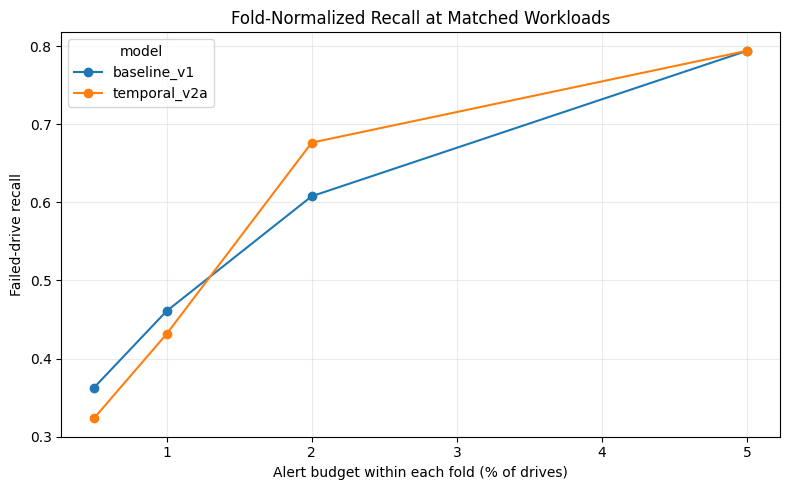

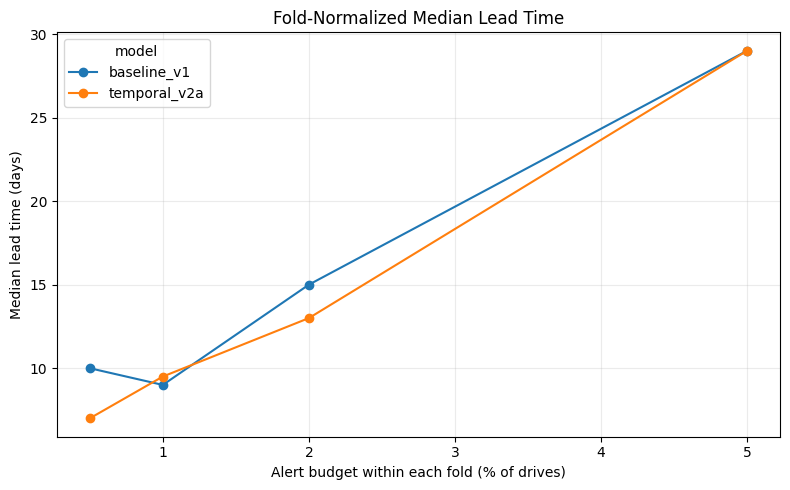

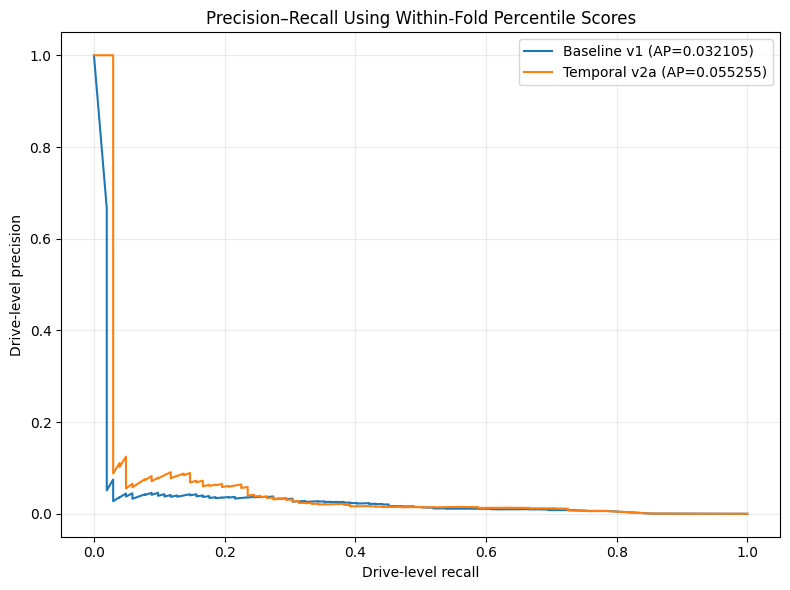

In [19]:
# ============================================================
# 19. Visual comparison
# ============================================================

recall_table = results.pivot(
    index="alert_budget_percent",
    columns="model",
    values="drive_recall",
).sort_index()

recall_table.plot(marker="o", figsize=(8, 5))
plt.xlabel("Alert budget within each fold (% of drives)")
plt.ylabel("Failed-drive recall")
plt.title("Fold-Normalized Recall at Matched Workloads")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

lead_table = results.pivot(
    index="alert_budget_percent",
    columns="model",
    values="median_lead_time_days",
).sort_index()

lead_table.plot(marker="o", figsize=(8, 5))
plt.xlabel("Alert budget within each fold (% of drives)")
plt.ylabel("Median lead time (days)")
plt.title("Fold-Normalized Median Lead Time")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_label, drive_df in [
    ("Baseline v1", baseline_drives),
    ("Temporal v2a", temporal_drives),
]:
    precision, recall, _ = precision_recall_curve(
        drive_df["drive_failed"],
        drive_df["within_fold_percentile"],
    )
    ap = average_precision_score(
        drive_df["drive_failed"],
        drive_df["within_fold_percentile"],
    )
    plt.plot(recall, precision, label=f"{model_label} (AP={ap:.6f})")

plt.xlabel("Drive-level recall")
plt.ylabel("Drive-level precision")
plt.title("Precision–Recall Using Within-Fold Percentile Scores")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Reading the 5% alert-budget row

The historical corrected run showed a very large boundary tie at the 5% budget (roughly 95% of a fold sharing the boundary score). That row is therefore **diagnostically weak and should not be over-interpreted**.

The lower alert budgets are much more informative. In the authoritative run:

| Alert budget | Baseline failed drives detected | Temporal failed drives detected |
|---:|---:|---:|
| 0.5% | 37 | 33 |
| 1% | 47 | 44 |
| 2% | 62 | 69 |
| 5% | 81 | 81 |

Temporal v2a wins at 2%, loses at 0.5% and 1%, and ties at 5%. This is **not consistent dominance**.


In [20]:
# ============================================================
# 20. Reliability gate and final model decision
# ============================================================

uses_decision_scores = (
    baseline_drives["score_type"].eq("decision_function").all()
    and temporal_drives["score_type"].eq("decision_function").all()
)

max_top_score_share = diagnostics["share_at_max_score"].max()
max_boundary_tie_share = results["max_boundary_tie_share"].max()

severe_top_saturation = max_top_score_share > MAX_ACCEPTABLE_TOP_SCORE_SHARE
severe_boundary_ties = max_boundary_tie_share > MAX_ACCEPTABLE_BOUNDARY_TIE_SHARE

wide_detected = results.pivot(
    index="alert_budget_fraction",
    columns="model",
    values="failed_drives_detected",
)

temporal_wins = int(
    (wide_detected["temporal_v2a"] > wide_detected["baseline_v1"]).sum()
)
temporal_ties = int(
    (wide_detected["temporal_v2a"] == wide_detected["baseline_v1"]).sum()
)

wide_lead = results.pivot(
    index="alert_budget_fraction",
    columns="model",
    values="median_lead_time_days",
)
lead_noninferior = int(
    (
        wide_lead["temporal_v2a"]
        >= wide_lead["baseline_v1"] - 7
    ).fillna(False).sum()
)

baseline_ap = ranking_summary.loc[
    ranking_summary["model"] == "baseline_v1",
    "drive_pr_auc_within_fold_percentile",
].iloc[0]

temporal_ap = ranking_summary.loc[
    ranking_summary["model"] == "temporal_v2a",
    "drive_pr_auc_within_fold_percentile",
].iloc[0]

ranking_improved = temporal_ap > baseline_ap

if not uses_decision_scores:
    decision = "RERUN_WITH_DECISION_SCORES"
    recommendation = (
        "Do not make a model decision from probability-only rankings. "
        "Regenerate OOF predictions with decision_function scores."
    )
elif ranking_improved and temporal_wins >= 3 and lead_noninferior >= 3:
    decision = "PROMOTE_TEMPORAL_V2A"
    recommendation = (
        "Temporal v2a consistently improves the corrected matched-workload screen."
    )
elif ranking_improved and (temporal_wins + temporal_ties) >= 3:
    decision = "BORDERLINE_REVIEW"
    recommendation = (
        "Temporal v2a improves ranking, but its operational advantage remains mixed."
    )
else:
    decision = "RETAIN_BASELINE_V1"
    recommendation = (
        "Temporal v2a does not show a reliable corrected matched-workload advantage. "
        "Retain the simpler Baseline v1."
    )

decision_summary = {
    "decision": decision,
    "recommendation": recommendation,
    "uses_decision_function_scores_for_both_models": bool(uses_decision_scores),
    "maximum_share_of_drives_at_fold_maximum_score": float(max_top_score_share),
    "maximum_boundary_tie_share": float(max_boundary_tie_share),
    "severe_top_score_saturation": bool(severe_top_saturation),
    "severe_boundary_ties": bool(severe_boundary_ties),
    "temporal_detection_wins_out_of_4_budgets": temporal_wins,
    "temporal_detection_ties_out_of_4_budgets": temporal_ties,
    "temporal_lead_time_noninferior_out_of_4_budgets": lead_noninferior,
    "baseline_percentile_drive_pr_auc": float(baseline_ap),
    "temporal_percentile_drive_pr_auc": float(temporal_ap),
}

print("=" * 76)
print("FINAL DECISION:", decision)
print(recommendation)
print("=" * 76)
print(json.dumps(decision_summary, indent=2))


FINAL DECISION: RETAIN_BASELINE_V1
Temporal v2a does not show a reliable corrected matched-workload advantage. Retain the simpler Baseline v1.
{
  "decision": "RETAIN_BASELINE_V1",
  "recommendation": "Temporal v2a does not show a reliable corrected matched-workload advantage. Retain the simpler Baseline v1.",
  "uses_decision_function_scores_for_both_models": true,
  "maximum_share_of_drives_at_fold_maximum_score": 1.073399025353685e-05,
  "maximum_boundary_tie_share": 0.9558446297667729,
  "severe_top_score_saturation": false,
  "severe_boundary_ties": true,
  "temporal_detection_wins_out_of_4_budgets": 1,
  "temporal_detection_ties_out_of_4_budgets": 1,
  "temporal_lead_time_noninferior_out_of_4_budgets": 4,
  "baseline_percentile_drive_pr_auc": 0.03210490671229353,
  "temporal_percentile_drive_pr_auc": 0.055254917585039316
}


# Conclusion

The targeted temporal feature branch was useful, but it did **not** justify replacing the established baseline.

The experiment produced three important lessons:

1. **The temporal features contain real ranking signal.** In the reduced screen, Temporal v2a improved mean PR-AUC / ROC-AUC and improved the corrected percentile PR-AUC.
2. **Probability-based operating comparisons can be misleading.** Saturated SGD probabilities made the first matched-workload approach unreliable; raw decision scores preserved the needed ordering.
3. **Extra complexity must win operationally, not just statistically.** At matched alert budgets, Temporal v2a did not consistently detect more failed drives than Baseline v1. It lost at 0.5% and 1%, won at 2%, and tied at 5%, where severe boundary ties further weaken interpretation.

Therefore the final project decision remains:

> **RETAIN BASELINE V1**

The simpler three-feature Logistic Regression baseline remains the final model because the temporal extension did not demonstrate a sufficiently consistent operational advantage to justify its added complexity.

This closes the technical modeling sequence. The next stage is reporting and portfolio presentation.
